In [ ]:
# prompt: import data science libraries, sns set theme, mount drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

sns.set_theme()

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data_path = '/content/drive/My Drive/DSO 574/assignments/assignment data/NBA Data/'

In [ ]:
files = os.listdir(data_path + 'Combined Files [With Game ID]')
files

['2016-2017_NBA_PbP_Logs.csv',
 '2014-2015_NBA_PbP_Logs.csv',
 '2013-2014_NBA_PbP_Logs.csv',
 '2015-2016_NBA_PbP_Logs.csv',
 '2021-2022_NBA_PbP_Logs.csv',
 '2017-2018_NBA_PbP_Logs.csv',
 '2019-2020_NBA_PbP_Logs.csv',
 '2022-2023_NBA_PbP_Logs.csv',
 '2018-2019_NBA_PbP_Logs.csv',
 '2020-2021_NBA_PbP_Logs.csv',
 '2023-2024_NBA_PbP_Logs.csv']

#Damian Lillard effect on the Bucks on and off the court

In [ ]:
years = ['2021-2022_NBA_PbP_Logs.csv', '2022-2023_NBA_PbP_Logs.csv', '2023-2024_NBA_PbP_Logs.csv']
bucks = pd.DataFrame()
for y in years:
  data = pd.read_csv(data_path + 'Combined Files [With Game ID]/' + y)
  bucks = pd.concat([bucks, data[data['matchup'].apply(lambda x: 'MIL' in x)]])
bucks

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,steal,type,shot_distance,original_x,original_y,converted_x,converted_y,description,matchup,game_name
1376,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,start of period,NaN,NaN,NaN,NaN,NaN,NaN,MIL@TOR,0022100329-MIL@TOR
1377,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,jump ball,NaN,NaN,NaN,NaN,NaN,Jump Ball Achiuwa vs. Portis: Tip to VanVleet,MIL@TOR,0022100329-MIL@TOR
1378,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,3pt pullup jump shot,26.0,96.0,247.0,34.6,64.3,Trent Jr. 27' 3PT Pullup Jump Shot (3 PTS) (Si...,MIL@TOR,0022100329-MIL@TOR
1379,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,turnaround fadeaway,12.0,-116.0,23.0,36.6,7.3,MISS Portis 12' Turnaround Fadeaway Shot,MIL@TOR,0022100329-MIL@TOR
1380,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,rebound offensive,NaN,NaN,NaN,NaN,NaN,Allen REBOUND (Off:1 Def:0),MIL@TOR,0022100329-MIL@TOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601722,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,free throw 1/2,NaN,NaN,NaN,NaN,NaN,Hield Free Throw 1 of 2 (7 PTS),IND@MIL,0022301229-IND@MIL
601723,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,free throw 2/2,NaN,NaN,NaN,NaN,NaN,Hield Free Throw 2 of 2 (8 PTS),IND@MIL,0022301229-IND@MIL
601724,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,driving layup,3.0,-10.0,27.0,24.0,86.3,MISS Middleton 3' Driving Layup,IND@MIL,0022301229-IND@MIL
601725,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,rebound defensive,NaN,NaN,NaN,NaN,NaN,Hield REBOUND (Off:4 Def:7),IND@MIL,0022301229-IND@MIL


In [ ]:
bucks['lillard'] = (bucks.iloc[:, 3:14] == 'Damian Lillard').sum(axis=1).astype(bool)
bucks['mil_offense'] = bucks.team == 'MIL'
bucks['game_min'] = bucks.elapsed.apply(lambda x: int(x.split(':')[1]))
bucks['period_min'] = bucks.period.astype(str) + '_' + bucks.game_min.astype(str)
bucks['description'] = bucks.description.astype(str)

In [ ]:
bucks

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,original_y,converted_x,converted_y,description,matchup,game_name,lillard,mil_offense,game_min,period_min
1376,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,NaN,NaN,nan,MIL@TOR,0022100329-MIL@TOR,False,False,0,1_0
1377,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,NaN,NaN,Jump Ball Achiuwa vs. Portis: Tip to VanVleet,MIL@TOR,0022100329-MIL@TOR,False,False,0,1_0
1378,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,247.0,34.6,64.3,Trent Jr. 27' 3PT Pullup Jump Shot (3 PTS) (Si...,MIL@TOR,0022100329-MIL@TOR,False,False,0,1_0
1379,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,23.0,36.6,7.3,MISS Portis 12' Turnaround Fadeaway Shot,MIL@TOR,0022100329-MIL@TOR,False,True,0,1_0
1380,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,NaN,NaN,Allen REBOUND (Off:1 Def:0),MIL@TOR,0022100329-MIL@TOR,False,True,0,1_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601722,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,NaN,NaN,Hield Free Throw 1 of 2 (7 PTS),IND@MIL,0022301229-IND@MIL,True,False,11,4_11
601723,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,NaN,NaN,Hield Free Throw 2 of 2 (8 PTS),IND@MIL,0022301229-IND@MIL,True,False,11,4_11
601724,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,27.0,24.0,86.3,MISS Middleton 3' Driving Layup,IND@MIL,0022301229-IND@MIL,True,True,11,4_11
601725,22301229,NBA 2023 In-Season Tournament,2023-12-07,Myles Turner,Buddy Hield,Bruce Brown,Tyrese Haliburton,Aaron Nesmith,Giannis Antetokounmpo,Brook Lopez,...,NaN,NaN,NaN,Hield REBOUND (Off:4 Def:7),IND@MIL,0022301229-IND@MIL,True,False,11,4_11


In [ ]:
# prompt: generate pivot table on 'hali', 'MIL_offense', and 'period_min' summing 'home_score' and 'away_score'

import pandas as pd
pivot_table_mil = pd.pivot_table(bucks, values=['home_score', 'away_score'], index=['lillard', 'mil_offense', 'period_min'], aggfunc='sum').reset_index()
pivot_table_mil

,lillard,mil_offense,period_min,away_score,home_score
0,False,False,1_0,521,620
1,False,False,1_1,2195,2494
2,False,False,1_10,23339,23933
3,False,False,1_11,29056,30688
4,False,False,1_12,10736,11214
...,...,...,...,...,...
249,True,True,6_0,702,702
250,True,True,6_1,468,468
251,True,True,6_2,351,351
252,True,True,6_3,958,966


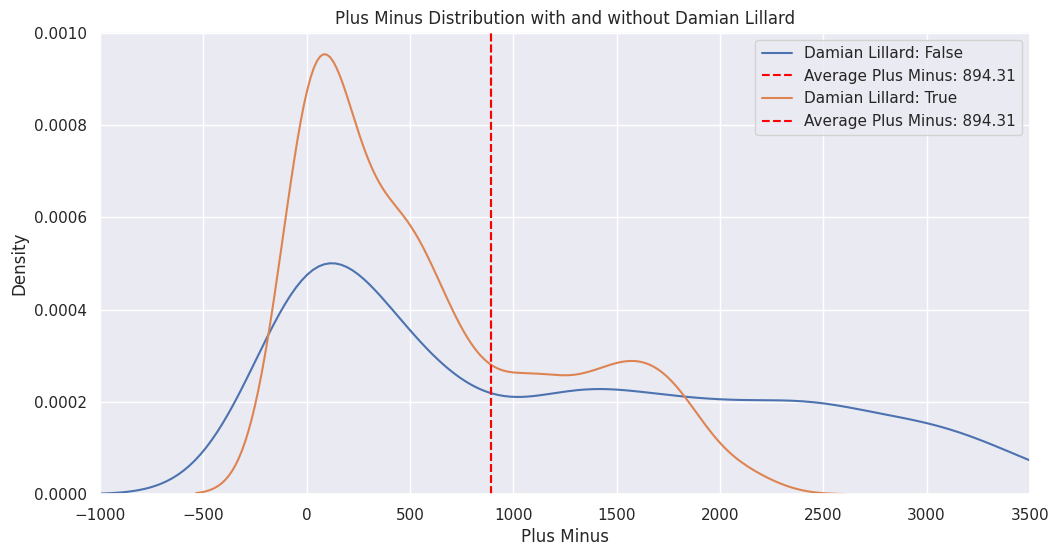

In [ ]:
# prompt: plot plus minus distribution for both values of Lillard on the same plot, remove the bars for each data_set

import matplotlib.pyplot as plt
# Assuming pivot_table_mil is defined as in your previous code

plt.figure(figsize=(12, 6))

for lillard_value in pivot_table_mil['lillard'].unique():
    subset = pivot_table_mil[pivot_table_mil['lillard'] == lillard_value]
    #plus_minus = subset['home_score'] - subset['away_score']
    plus_minus_per_game = subset['home_score'] - subset['away_score']
    sns.kdeplot(
        plus_minus_per_game,
        label=f'Damian Lillard: {lillard_value}',
        bw_adjust=0.7,
        common_norm=False  # Prevents scaling by number of observations
    )
    #sns.kdeplot(subset['home_score'] - subset['away_score'], label=f'Damian Lillard: {lillard_value}')
    avg_plus_minus = pivot_table_mil['home_score'] - pivot_table_mil['away_score'].mean()
    plt.axvline(x=avg_plus_minus.mean(), color='red', linestyle='--', label=f'Average Plus Minus: {avg_plus_minus.mean():.2f}')


plt.xlim(-1000, 3500)
plt.xlabel('Plus Minus')
plt.ylabel('Density')
plt.title('Plus Minus Distribution with and without Damian Lillard')
plt.legend()
plt.show()

In [ ]:
# prompt: add a t-test that compares plus minus with haliburton on court vs haliburton not on court

from scipy import stats

# Assuming pivot_table_ind is defined as in your previous code

lillard_on = pivot_table_mil[pivot_table_mil['lillard'] == True]['home_score'] - pivot_table_mil[pivot_table_mil['lillard'] == True]['away_score']
lillard_off = pivot_table_mil[pivot_table_mil['lillard'] == False]['home_score'] - pivot_table_mil[pivot_table_mil['lillard'] == False]['away_score']

t_statistic, p_value = stats.ttest_ind(lillard_on, lillard_off)

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("There is a statistically significant difference in shot percentage with and without Lillard on the court.")
else:
    print("There is no statistically significant difference in shot percentage with and without Lillard on the court.")


T-statistic: -4.930583197762932
P-value: 1.4885551558379535e-06
There is a statistically significant difference in shot percentage with and without Lillard on the court.


In [ ]:
mil_off = bucks[(bucks.mil_offense) & (bucks.data_set.astype(str).apply(lambda x: 'Regular' in x))].copy()
mil_off['misses'] = mil_off.description.apply(lambda x: 'MISS' in x)
mil_off['makes'] = mil_off.description.apply(lambda x: 'PTS' in x) & mil_off.description.astype(str).apply(lambda x: 'Free Throw' not in x)
mil_off

,game_id,data_set,date,a1,a2,a3,a4,a5,h1,h2,...,converted_y,description,matchup,game_name,lillard,mil_offense,game_min,period_min,misses,makes
1379,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,7.3,MISS Portis 12' Turnaround Fadeaway Shot,MIL@TOR,0022100329-MIL@TOR,False,True,0,1_0,True,False
1380,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,NaN,Allen REBOUND (Off:1 Def:0),MIL@TOR,0022100329-MIL@TOR,False,True,0,1_0,False,False
1381,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,29.7,MISS Allen 26' 3PT Jump Shot,MIL@TOR,0022100329-MIL@TOR,False,True,0,1_0,True,False
1384,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,9.9,MISS Connaughton 7' Turnaround Hook Shot,MIL@TOR,0022100329-MIL@TOR,False,True,1,1_1,True,False
1387,22100329,2021-22 Regular Season,2021-12-02,Bobby Portis,Grayson Allen,Pat Connaughton,Jrue Holiday,Khris Middleton,Precious Achiuwa,Fred VanVleet,...,4.5,MISS Allen 3PT Jump Shot,MIL@TOR,0022100329-MIL@TOR,False,True,1,1_1,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591334,22300286,NBA 2023-2024 Regular Season,2023-12-02,De'Andre Hunter,Dejounte Murray,Trae Young,Saddiq Bey,Clint Capela,Brook Lopez,Khris Middleton,...,85.8,Lillard 3' Cutting Dunk Shot (25 PTS) (G. Ante...,ATL@MIL,0022300286-ATL@MIL,True,True,10,4_10,False,True
591336,22300286,NBA 2023-2024 Regular Season,2023-12-02,De'Andre Hunter,Dejounte Murray,Trae Young,Saddiq Bey,Clint Capela,Brook Lopez,Khris Middleton,...,NaN,BUCKS Rebound,ATL@MIL,0022300286-ATL@MIL,True,True,10,4_10,False,False
591337,22300286,NBA 2023-2024 Regular Season,2023-12-02,De'Andre Hunter,Dejounte Murray,Trae Young,Saddiq Bey,Clint Capela,Brook Lopez,Khris Middleton,...,87.8,B. Lopez 1' Reverse Layup (11 PTS),ATL@MIL,0022300286-ATL@MIL,True,True,11,4_11,False,True
591339,22300286,NBA 2023-2024 Regular Season,2023-12-02,De'Andre Hunter,Dejounte Murray,Trae Young,Saddiq Bey,Clint Capela,Brook Lopez,Khris Middleton,...,NaN,G. Antetokounmpo REBOUND (Off:2 Def:9),ATL@MIL,0022300286-ATL@MIL,True,True,11,4_11,False,False


In [ ]:
# prompt: generate pivot table for mil_off for lillard and sum of misses and makes

import pandas as pd
pivot_table_mil_off = pd.pivot_table(mil_off, values=['misses', 'makes'], index=['lillard', 'period_min'], aggfunc='sum').reset_index()
pivot_table_mil_off['shots'] = pivot_table_mil_off['misses'] + pivot_table_mil_off['makes']
pivot_table_mil_off['shot_pct'] = pivot_table_mil_off['makes'] / pivot_table_mil_off['shots']
pivot_table_mil_off

,lillard,period_min,makes,misses,shots,shot_pct
0,False,1_0,130,174,304,0.427632
1,False,1_1,181,191,372,0.486559
2,False,1_10,169,213,382,0.442408
3,False,1_11,176,233,409,0.430318
4,False,1_12,20,47,67,0.298507
...,...,...,...,...,...,...
122,True,6_0,0,2,2,0.000000
123,True,6_1,0,2,2,0.000000
124,True,6_2,0,2,2,0.000000
125,True,6_3,2,2,4,0.500000


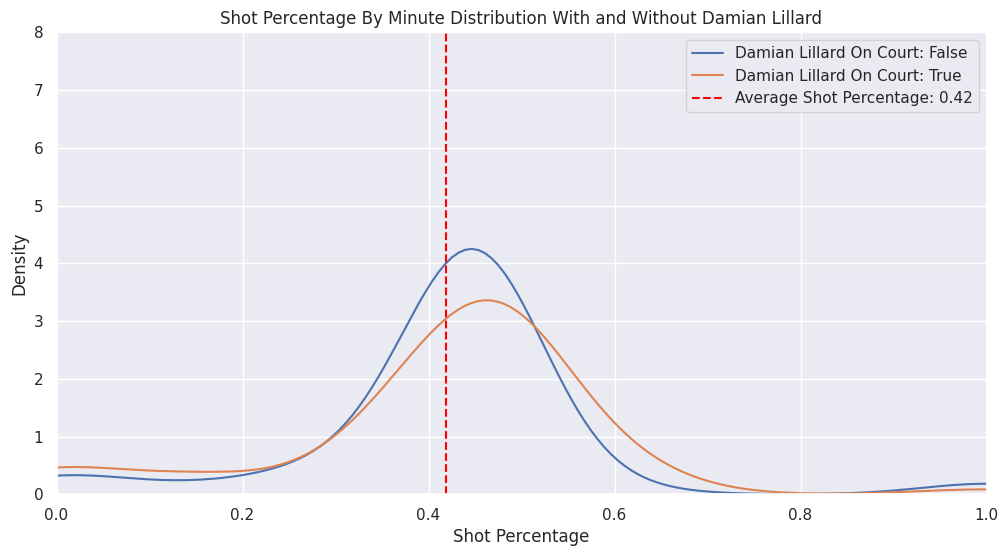

In [ ]:
plt.figure(figsize=(12, 6))

for lillard_value in pivot_table_mil_off['lillard'].unique():
  subset = pivot_table_mil_off[pivot_table_mil_off['lillard'] == lillard_value]
  sns.kdeplot(subset['shot_pct'], label=f'Damian Lillard On Court: {lillard_value}')

avg_shot_pct = pivot_table_mil_off['shot_pct'].mean()
plt.axvline(x=avg_shot_pct, color='red', linestyle='--', label=f'Average Shot Percentage: {avg_shot_pct:.2f}')

plt.xlabel('Shot Percentage')
plt.xlim(0, 1)
plt.ylabel('Density')
plt.ylim(0, 8)
plt.title('Shot Percentage By Minute Distribution With and Without Damian Lillard')
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

# Separate shot percentages based on Lillard's presence
lillard_on_court = pivot_table_mil_off[pivot_table_mil_off['lillard'] == True]['shot_pct']
lillard_off_court = pivot_table_mil_off[pivot_table_mil_off['lillard'] == False]['shot_pct']

# Perform the t-test
t_statistic, p_value = ttest_ind(lillard_on_court, lillard_off_court)

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("There is a statistically significant difference in shot percentage with and without Lillard on the court.")
else:
    print("There is no statistically significant difference in shot percentage with and without Lillard on the court.")

T-statistic: nan
P-value: nan
There is no statistically significant difference in shot percentage with and without Lillard on the court.


In [ ]:
lillard_off_2224 = mil_off[(mil_off.lillard) & (mil_off.data_set.astype(str).apply(lambda x: '23' in x))].copy()
# get only plays where booker is involved in the action
hali_off_2224 = lillard_off_2224[lillard_off_2224.description.apply(lambda x: 'Lillard' in x)]

In [ ]:
lillard_off_2224['lillard_shot'] = (lillard_off_2224.description.apply(lambda x: '(lillard' not in x)) \
      & (lillard_off_2224['type'].apply(lambda x: 'shot' in x or 'layup' in x or 'fadeaway' in x or 'dunk' in x))

In [ ]:
lillard_shot_2224 = lillard_off_2224[(lillard_off_2224.lillard_shot) | (lillard_off_2224['type'].apply(lambda x: 'free throw' in x or 'technical' in x))].copy()
lillard_shot_2224['FT'] = lillard_shot_2224['type'].apply(lambda x: 'free throw' in x or 'technical' in x)
lillard_shot_2224['FT_make'] = (lillard_shot_2224.FT) & (lillard_shot_2224.description.apply(lambda x: 'MISS' not in x))
lillard_shot_2224['shot'] = ~lillard_shot_2224.FT
lillard_shot_2224['shot_make'] = lillard_shot_2224.shot & (lillard_shot_2224.description.apply(lambda x: 'MISS' not in x))

In [ ]:
lillard_shot_2224['3PT'] = ((lillard_shot_2224.shot_distance >= 22) & (lillard_shot_2224['type'].apply(lambda x: '3pt' in x)))
lillard_shot_2224['midrange'] = ((lillard_shot_2224.shot_distance <= 24) & (lillard_shot_2224.shot_distance > 10) & (lillard_shot_2224['type'].apply(lambda x: '3pt' not in x)))
lillard_shot_2224['close'] = (lillard_shot_2224.shot_distance <= 10)

In [ ]:
pivot_table_shot_lillard = pd.pivot_table(lillard_shot_2224, values=['shot', 'shot_make'],
                                              index=['3PT', 'midrange', 'close', 'period_min'],
                                              aggfunc='sum').reset_index()
pivot_table_shot_lillard

In [ ]:
# prompt: using pivot_table_shot_hali, split into 3 plots, one for each shot category

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

for i, shot_type in enumerate(['3PT', 'midrange', 'close']):
  plt.subplot(1, 3, i + 1)
  subset = pivot_table_shot_lillard[pivot_table_shot_lillard[shot_type]]
  if not subset.empty:
      shot_pct = subset['shot_make'] / subset['shot']
      sns.kdeplot(subset['shot'], bw_adjust=0.7, label=f'{shot_type}')
  plt.xlabel('Shot Count')
  plt.xlim(0, 30)
  plt.ylabel('Proportion')
  plt.title(f'Lillard {shot_type} Shot Distribution')
  plt.legend()

plt.tight_layout()
plt.show()
